# DATA

In [16]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("gopalbhattrai/pascal-voc-2012-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset


# Code

In [17]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

In [48]:
class YOLO_v1(nn.Module):
    def __init__(self,split_size=7, num_boxes=2, num_classes=20):
        super(YOLO_v1, self).__init__()
        self.split_size = split_size
        self.num_boxes = num_boxes
        self.features = nn.Sequential(
            # --- KHỐI 1 ---
            # Output: (64, 224, 224)
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.1),
            # Output: (64, 112, 112)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 2 ---
            # Output: (192, 112, 112)
            nn.Conv2d(64, 192, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(192),
            nn.LeakyReLU(0.1),
            # Output: (192, 56, 56)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 3 (Lặp tuần tự các cặp 1x1 và 3x3) ---
            # Output: (128, 56, 56)
            nn.Conv2d(192, 128, kernel_size=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.1),

            # Output: (256, 56, 56)
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),

            # Output: (256, 56, 56)
            nn.Conv2d(256, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),

            # Output: (512, 56, 56)
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Output: (512, 28, 28)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 4 (Cấu trúc lặp lại 4 lần cặp Conv 1x1 và 3x3) ---
            # Lần 1
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Lần 2
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Lần 3
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Lần 4
            nn.Conv2d(512, 256, kernel_size=1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.1),
            nn.Conv2d(256, 512, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),

            # Thêm 2 lớp Conv phụ trước khi Downsample
            # Output: (512, 28, 28)
            nn.Conv2d(512, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            # Output: (1024, 28, 28)
            nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Output: (1024, 14, 14)
            nn.MaxPool2d(kernel_size=2, stride=2),

            # --- KHỐI 5 (Cấu trúc lặp lại 2 lần cặp Conv 1x1 và 3x3) ---
            # Lần 1
            nn.Conv2d(1024, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Lần 2
            nn.Conv2d(1024, 512, kernel_size=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.1),
            nn.Conv2d(512, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Các lớp Conv cuối cùng để hạ kích thước về đúng lưới mong muốn
            # Output: (1024, 14, 14)
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Ổn định kích thước hình học bằng Stride=2 ở Conv thay vì dùng MaxPool
            # Output: (1024, 7, 7)
            nn.Conv2d(1024, 1024, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Hai lớp Conv cuối cùng chuẩn bị cho tầng Fully Connected
            # Output: (1024, 7, 7)
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),

            # Output: (1024, 7, 7)
            nn.Conv2d(1024, 1024, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.LeakyReLU(0.1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(1024 * split_size * split_size,4096),
            nn.Dropout(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(4096,(split_size * split_size *  (num_classes + num_boxes * 5)))
        )


    def forward(self,X):
        feature = self.features(X)
        fc =self.fc(feature)
        return fc # Can reshape neu muon shape dang (split_size,split_size,C + B*2)

In [19]:
def calculate_IOU(predict,ground_truth): #Bao gom (B,S,S,4)
    min_predict_x = predict[...,0:1] - predict[...,2:3] / 2
    max_predict_x = predict[...,0:1] + predict[...,2:3] / 2
    min_predict_y = predict[...,1:2] - predict[...,3:4] / 2
    max_predict_y = predict[...,1:2] + predict[...,3:4] /2

    min_GT_x = ground_truth[...,0:1] - ground_truth[...,2:3] / 2
    max_GT_x = ground_truth[...,0:1] +  ground_truth[...,2:3] / 2
    min_GT_y  = ground_truth[...,1:2] - ground_truth[...,3:4] /2
    max_GT_y  = ground_truth[...,1:2] + ground_truth[...,3:4] /2

    Intersection_X = torch.min(max_predict_x,max_GT_x) - torch.max(min_predict_x,min_GT_x)
    Intersection_Y =  torch.min(max_predict_y,max_GT_y) - torch.max(min_predict_y,min_GT_y)

    Intersection = Intersection_X.clamp(0) * Intersection_Y.clamp(0)

    Union = predict[...,2:3] * predict[...,3:4] + ground_truth[...,2:3] * ground_truth[...,3:4] - Intersection

    return Intersection / (Union + 1e-6)



# Loss 

In [20]:
def convert_to_absolute(boxes, S=7):
    """ Chuyển đổi bounding box từ hệ tọa độ cell-relative sang hệ tọa độ toàn ảnh 
        Input se la (b,7,7,4)
    """
    device = boxes.device
    # Tạo ma trận lưới tọa độ
    cell_y, cell_x = torch.meshgrid(torch.arange(S, device=device), torch.arange(S, device=device), indexing='ij')
    
    # Reshape để broadcast với shape (Batch, 7, 7, 4) hoặc (7, 7, 4)
    cell_x = cell_x.unsqueeze(-1)
    cell_y = cell_y.unsqueeze(-1)
    
    abs_x = (boxes[..., 0:1] + cell_x) / S
    abs_y = (boxes[..., 1:2] + cell_y) / S
    
    # w và h đã là giá trị so với toàn ảnh nên ta giữ nguyên
    return torch.cat([abs_x, abs_y, boxes[..., 2:4]], dim=-1)

In [21]:
class Loss_YOLO(nn.Module):
    def __init__(self, split_size, B, C, lambda_coor, lambda_noobj):
        super(Loss_YOLO, self).__init__()
        self.split_size = split_size
        self.B = B
        self.C = C
        self.lambda_coor = lambda_coor
        self.lambda_noobj = lambda_noobj
        self.loss = nn.MSELoss(reduction="sum") 
        
    def forward(self, predict, ground_truth):
        predict = predict.reshape(-1, self.split_size, self.split_size, self.C + self.B * 5)
        exist_boxes = ground_truth[..., 20:21] # Lấy cột exist ra (N, 7, 7, 1)

        # Dang dung tọa độ center
        abs_predict_1 = predict[..., 21:25]
        abs_predict_2 = predict[..., 26:30]
        abs_gt = ground_truth[..., 21:25]

        IOU_1 = calculate_IOU(abs_predict_1, abs_gt)
        IOU_2 = calculate_IOU(abs_predict_2, abs_gt)
        IOU = torch.cat([IOU_1.unsqueeze(0), IOU_2.unsqueeze(0)], dim=0)

        val_IOU, ind_IOU = torch.max(IOU, dim=0) 
        
        # Tạo mask xác định Bounding Box nào đang chịu trách nhiệm
        box1_responsible = (1 - ind_IOU) * exist_boxes
        box2_responsible = ind_IOU * exist_boxes

        # --- Lấy Box chịu trách nhiệm ra để tính MSE Loss (vẫn dùng hệ tọa độ gốc) ---
        best_BBox = box1_responsible * predict[..., 21:25] + box2_responsible * predict[..., 26:30]
        GT_BBox = ground_truth[..., 21:25] * exist_boxes 

        mse_loss_xy = self.loss(
            torch.flatten(best_BBox[..., 0:2], end_dim=-2),
            torch.flatten(GT_BBox[..., 0:2], end_dim=-2)
        )

        best_BBox_wh_sqrt = torch.sign(best_BBox[..., 2:4]) * torch.sqrt(torch.abs(best_BBox[..., 2:4]) + 1e-6)
        GT_BBox_wh_sqrt = torch.sqrt(GT_BBox[..., 2:4])

        mse_loss_wh = self.loss(
            torch.flatten(best_BBox_wh_sqrt, end_dim=-2),
            torch.flatten(GT_BBox_wh_sqrt, end_dim=-2)
        )

        mse_loss = mse_loss_xy + mse_loss_wh

        #TÍNH OBJECT LOSS
        best_conf = box1_responsible * predict[..., 20:21] + box2_responsible * predict[..., 25:26]
        obj_loss = self.loss(torch.flatten(best_conf), torch.flatten(exist_boxes))

        #
        noobj_loss = self.loss(
            torch.flatten((1 - box1_responsible) * predict[..., 20:21]),
            torch.flatten((1 - box1_responsible) * ground_truth[..., 20:21])
        )
        noobj_loss += self.loss(
            torch.flatten((1 - box2_responsible) * predict[..., 25:26]),
            torch.flatten((1 - box2_responsible) * ground_truth[..., 20:21])
        )
        probas_loss = self.loss(
            torch.flatten(predict[..., :20] * exist_boxes, end_dim=-2),
            torch.flatten(ground_truth[..., :20] * exist_boxes, end_dim=-2)
        )

        loss = mse_loss * self.lambda_coor + obj_loss + self.lambda_noobj * noobj_loss + probas_loss
        return loss

In [22]:
path

'/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset'

# PRINT XML FILE Function

In [23]:
import os
import torch
import xml.etree.ElementTree as ET
from PIL import Image
from torch.utils.data import Dataset
def print_xml_structure(element, level=0):
    # In tên thẻ kèm theo khoảng trống thụt lề tùy theo cấp độ (level)
    print("    " * level + f"|-- <{element.tag}>")
    
    # Đệ quy để in tiếp các thẻ con bên trong
    for child in element:
        print_xml_structure(child, level + 1)

In [24]:
tree = ET.parse("/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations/2007_000027.xml")
root = tree.getroot()
print_xml_structure(root)

|-- <annotation>
    |-- <folder>
    |-- <filename>
    |-- <source>
        |-- <database>
        |-- <annotation>
        |-- <image>
    |-- <size>
        |-- <width>
        |-- <height>
        |-- <depth>
    |-- <segmented>
    |-- <object>
        |-- <name>
        |-- <pose>
        |-- <truncated>
        |-- <difficult>
        |-- <bndbox>
            |-- <xmin>
            |-- <ymin>
            |-- <xmax>
            |-- <ymax>
        |-- <part>
            |-- <name>
            |-- <bndbox>
                |-- <xmin>
                |-- <ymin>
                |-- <xmax>
                |-- <ymax>
        |-- <part>
            |-- <name>
            |-- <bndbox>
                |-- <xmin>
                |-- <ymin>
                |-- <xmax>
                |-- <ymax>
        |-- <part>
            |-- <name>
            |-- <bndbox>
                |-- <xmin>
                |-- <ymin>
                |-- <xmax>
                |-- <ymax>
        |-- <part>
      

# Dataset and DataLoader

## Lỗi sai trong Phần DataSet ở dưới(đã fix) !
> https://gemini.google.com/share/dbd54c00b726


In [25]:
mapp = {
            "aeroplane": 0, "bicycle": 1, "bird": 2, "boat": 3, "bottle": 4,
            "bus": 5, "car": 6, "cat": 7, "chair": 8, "cow": 9, "diningtable": 10,
            "dog": 11, "horse": 12, "motorbike": 13, "person": 14, "pottedplant": 15,
            "sheep": 16, "sofa": 17, "train": 18, "tvmonitor": 19
        }

for obj in root.findall('object'):
    main_name = obj.find('name').text
    print(mapp[main_name])

14


In [26]:
class PascalVOCDataset(Dataset):
    def __init__(self, xml_dir, img_dir, S=7, B=2, C=20, transform=None):
        self.xml_dir = xml_dir
        self.img_dir = img_dir
        self.S = S
        self.B = B
        self.C = C
        self.transform = transform
        # Tách tên file và đuôi file ra, chỉ lấy phần tên [0]
        self.filenames = [os.path.splitext(f)[0] for f in os.listdir(xml_dir) if f.endswith('.xml')]

        # Bảng ánh xạ 20 class chuẩn của Pascal VOC thành dạng số (0 -> 19)
        self.classes_mapping = {
            "aeroplane": 0, "bicycle": 1, "bird": 2, "boat": 3, "bottle": 4,
            "bus": 5, "car": 6, "cat": 7, "chair": 8, "cow": 9, "diningtable": 10,
            "dog": 11, "horse": 12, "motorbike": 13, "person": 14, "pottedplant": 15,
            "sheep": 16, "sofa": 17, "train": 18, "tvmonitor": 19
        }

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, index):
        img_path = os.path.join(self.img_dir, self.filenames[index] + ".jpg")
        image = Image.open(img_path).convert("RGB")

        xml_path = os.path.join(self.xml_dir,self.filenames[index] + ".xml")
        tree = ET.parse(xml_path)
        root = tree.getroot()

        width = float(root.find('size').find('width').text)
        height = float(root.find('size').find('height').text)

        check_tensor = torch.zeros(self.S,self.S,self.B * 5 + self.C)
        
        for obj in root.findall('object'):
            name = obj.find('name').text
            if name not in self.classes_mapping:
                continue
            class_idx = self.classes_mapping[name]
            
            bbox  = obj.find('bndbox')
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)

            
            x = (xmin + xmax) / (2.0 * width)
            y = (ymax + ymin) / (2.0 * height)
            w = (xmax - xmin) / width
            h = (ymax - ymin) / height

            num_blocks_x = min(int(x * self.S), self.S - 1) # Lưu ý có thể bị sai khi x = 1.0 --> x * self.S = 7
            num_blocks_y = min(int(y * self.S), self.S - 1)
            
            if check_tensor[num_blocks_y,num_blocks_x,20] == 0:
                # Ca hai deu bi fix trong range(0,1)
                coor_x_in_cell = x * self.S - num_blocks_x
                coor_y_in_cell = y * self.S - num_blocks_y
                
                check_tensor[num_blocks_y,num_blocks_x,21:25] = torch.tensor([coor_x_in_cell,coor_y_in_cell,w,h])

                check_tensor[num_blocks_y,num_blocks_x,20] = 1
                check_tensor[num_blocks_y,num_blocks_x,class_idx] = 1

        # Áp dụng các phép biến đổi Augmentation/Resize (nếu có)
        if self.transform:
            image = self.transform(image)

        return image, check_tensor

In [27]:
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

def train_fn(train_loader, model, optimizer, criterion, DEVICE):
    model.train()
    total_epoch_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        images, targets = images.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        total_epoch_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            print(f"Batch [{batch_idx + 1}/{len(train_loader)}] | Batch Loss: {loss.item():.4f}")

    print(f"==> Toàn bộ Epoch Loss: {total_epoch_loss / len(train_loader):.4f}")
    return total_epoch_loss / len(train_loader)

def val_fn(val_loader,model,criterion,DEVICE):
    with torch.no_grad():
        model.eval()
        total_epoch_loss = 0.0
    
        for batch_idx, (images, targets) in enumerate(val_loader):
            images, targets = images.to(DEVICE), targets.to(DEVICE)
            outputs = model(images)
    
            loss = criterion(outputs, targets)
            total_epoch_loss += loss.item()
        return total_epoch_loss / len(val_loader)




DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
EPOCHS = 5

transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
])

XML_TRAINVAL_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/Annotations"
IMG_TRAINVAL_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages"

XML_TEST_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/Annotations"
IMG_TEST_DIR = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/JPEGImages"




In [28]:
import torch
from torch.utils.data import random_split

 
train_val_dataset = PascalVOCDataset(xml_dir=XML_TRAINVAL_DIR, img_dir=IMG_TRAINVAL_DIR, transform=transform)
test_dataset = PascalVOCDataset(xml_dir = XML_TEST_DIR,img_dir = IMG_TEST_DIR,transform = transform)

train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size

train_dataset,val_dataset = random_split(train_val_dataset,[train_size,val_size])
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    drop_last=True
)
val_loader = DataLoader(
    dataset = val_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True,
    num_workers = 4,
    drop_last = True
)
test_loader = DataLoader(
    dataset = test_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False,
    num_workers = 4,
    drop_last = False
)

In [29]:
print(len(train_loader))
len(val_loader)

856


214

In [30]:
# Lấy 1 batch từ val_loader
images, targets = next(iter(train_loader))
for y in range(7):
    for x in range(7):
        if targets[0, y, x, 20] == 1:
            print(f"--- Tìm thấy vật thể ở ô lưới [Hàng {y}, Cột {x}] ---")
            print("Vector 30 phần tử của ô này:")
            print(targets[0, y, x])
            break

--- Tìm thấy vật thể ở ô lưới [Hàng 2, Cột 0] ---
Vector 30 phần tử của ô này:
tensor([0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 1.0000, 0.6300, 0.7222, 0.0520, 0.0889, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000])
--- Tìm thấy vật thể ở ô lưới [Hàng 3, Cột 1] ---
Vector 30 phần tử của ô này:
tensor([0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 1.0000, 0.6380, 0.7528, 0.0560, 0.0944, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000])
--- Tìm thấy vật thể ở ô lưới [Hàng 4, Cột 3] ---
Vector 30 phần tử của ô này:
tensor([0.0000, 0.0000, 1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 1.0000, 0.4860, 0.8611, 0.0600, 0

In [32]:
import torch.optim as optim
model = YOLO_v1(7,2,20)
model.to(DEVICE)
optimizer = optim.AdamW(model.parameters(),lr = LEARNING_RATE)
criterion = Loss_YOLO(7,2,20,5,0.5)

In [33]:
def train(MODEL_FILE):
    best_val_loss = torch.inf
    model.train()
    train_loss_his = []
    val_loss_his = []
    for epoch in range(EPOCHS):
        avg_train_loss = train_fn(train_loader,model,optimizer,criterion,DEVICE)
        avg_val_loss = val_fn(val_loader,model,criterion,DEVICE)
        print(f"EPOCH: {epoch + 1}: Train Loss: {avg_train_loss} ---- Val Loss: {avg_val_loss}")
        train_loss_his.append(avg_train_loss)
        val_loss_his.append(avg_val_loss)
        if(best_val_loss > avg_val_loss):
            best_val_loss = avg_val_loss
            print("Best model is saved !!!")
            torch.save(model.state_dict(),MODEL_FILE)

    return train_loss_his,val_loss_his

            

# Inference_function

## NMS

In [86]:
def NMS(bboxes,iou_threshold = 0.5,threshold = 0.4):
    """
        Parameters:
        bboxes (list): list of lists containing all bboxes with each bboxes
        specified as [class_pred, prob_score, x1, y1, x2, y2]
        iou_threshold (float): threshold where predicted bboxes is correct
        threshold (float): threshold to remove predicted bboxes (independent of IoU) 

    Returns:
        list: bboxes after performing NMS given a specific IoU threshold
    """
    bboxes = [box for box in bboxes if box[1] > threshold]
    sorted_bboxes = sorted(bboxes,key = lambda x: x[1],reverse = True)
    bboxes_res = []
    while sorted_bboxes:
        chosen_box = sorted_bboxes.pop(0)
        sorted_bboxes = [box for box in sorted_bboxes if chosen_box[0] != box[0] or 
                         calculate_IOU(box,chosen_box) < iou_threshold]
        bboxes_res.append(chosen_box)
    return bboxes_res

## mAP


[Exphain about trapezoid](https://gemini.google.com/share/3ef47d4c761a)

In [117]:
from collections import Counter

def mAP(pred_boxes, true_boxes, iou_threshold=0.5, num_classes=20,epsilon = 1e-6):
    """
    Parameters:
        pred_boxes (list): list of lists containing all bboxes with each bboxes
        specified as [train_idx, class_prediction, prob_score, x1, y1, x2, y2] # Corners Coordinate
        true_boxes (list): Similar as pred_boxes except all the correct ones 
        iou_threshold (float): threshold where predicted bboxes is correct
        num_classes (int): number of classes

    Returns:
        float: mAP value across all classes given a specific IoU threshold 
    """
    AP = []
    for c in range(num_classes):
        c_pred_boxes = [box for box in pred_boxes if box[1] == c]
        c_true_boxes = [box for box in true_boxes if box[1] == c]
        # Sort theo confident score
        c_pred_boxes = sorted(c_pred_boxes,key = lambda x: x[2],reverse = True)

        num_true_boxes = Counter(box[0] for box in c_true_boxes)
        
        # Key là train_idx nhé
        for key,val in num_true_boxes.items():
            num_true_boxes[key] = torch.zeros(val,dtype = torch.bool)

        TP = torch.zeros(len(c_pred_boxes))
        FP = torch.zeros(len(c_pred_boxes))
        
        for i,pred_box in enumerate(c_pred_boxes):
            idx = pred_box[0]
            same_idx_true_boxes = [box for box in c_true_boxes if box[0] == idx]

            best_IOU_score = 0
            idx_best_IOU = -1
            for (index,true_box) in enumerate(same_idx_true_boxes):
                IOU =  calculate_IOU(torch.tensor(true_box),torch.tensor(pred_box)
                                    )
                
                if(IOU > best_IOU_score):
                    best_IOU_score = IOU
                    idx_best_IOU = idx
            
            if(best_IOU_score > iou_threshold):
                if ~num_true_boxes[idx][index]:
                    TP[i] = 1
                    num_true_boxes[idx][index] = True
                else:
                    FP[i] = 1
            else:
                FP[i] = 1
        TP_cumsum = torch.cumsum(TP,dim = 0)
        FP_cumsum = torch.cumsum(FP,dim = 0)
        
        Precision = torch.divide(TP_cumsum,TP_cumsum + FP_cumsum + epsilon)
        Recall = TP_cumsum/ (len(c_true_boxes) + epsilon)

        Precision = torch.cat([torch.tensor([1]),Precision],dim = 0)
        Recall = torch.cat([torch.tensor([0]),Recall],dim = 0)

        AP.append(torch.trapezoid(Precision,Recall))
    return sum(AP) / len(AP)

In [188]:
def convert_bboxes(inputs): # b,7,7,30
    """
    This function help to convert the bboxes(b,7,7,30) to 
    [train_idx, class_prediction, prob_score, x1, y1, x2, y2]
    Notice that each of separate block in grid must have only one bboxes
    """

    conf = torch.cat([inputs[...,20:21],inputs[...,25:26]],dim = -1)
    best_conf,best_conf_indices = torch.max(conf,dim = -1) # b,7,7,1
    best_conf = best_conf.unsqueeze(-1)
    
    class_idx = torch.argmax(inputs[...,:20],dim = -1).unsqueeze(-1) # b,7,7,1
    bboxes_1 = inputs[...,21:25]
    bboxes_2 = inputs[...,26:30]
    
    chosen_bboxes = (1 - best_conf) * bboxes_1 + best_conf * bboxes_2
    chosen_bboxes = convert_to_absolute(chosen_bboxes) # b,7,7,4
    res = torch.cat([class_idx,best_conf,chosen_bboxes],dim = -1)
    print(res.shape)
    return res.reshape(res.shape[0],-1,res.shape[3])

In [122]:
def inference(dataloader,model,iou_threshold = 0.5,threshold = 0.4,num_classes=20,device = DEVICE):
    model.eval()
    model.to(device)
    with torch.no_grad():
        count = 0
        pred_bboxes = []
        true_bboxes = []
        for i,(inputs,targets) in enumerate(dataloader):
            inputs = inputs.to(device)
            targets = targets.to(device)
            # batch,7,7,30
            outputs = model(inputs).reshape(targets.shape)
            targets = convert_bboxes(targets)
            outputs = convert_bboxes(outputs)
            
            for i in range(inputs.shape[0]): # Batch size
                after_NMS_pred_bboxes = NMS(outputs[i],iou_threshold = 0.5,threshold = 0.4)
    
                for pred_box in after_NMS_pred_bboxes:
                    pred_bboxes.append([count] + pred_box.tolist())
                for true_box in after_NMS_pred_bboxes:
                    if true_box[2] > threshold:
                        true_bboxes.append([count] + true_box.tolist())
                count += 1
    print(f"mAP Score of this model is:{mAP(pred_bboxes,true_bboxes,iou_threshold = iou_threshold)*100:.2f}%")

In [37]:
import torch
a = torch.tensor([1,2,3,4])
b = torch.tensor([1,2,3,4])
torch.trapezoid(a,b)

tensor(7.5000)

# Training Period

In [140]:
MODEL_FILE = "model.pth"
train_loss,val_loss = train(MODEL_FILE)

Batch [100/856] | Batch Loss: 90.6332


KeyboardInterrupt: 

# Plot Train,Validation Loss and prediction Image

In [207]:
import matplotlib.pyplot as plt
import matplotlib as mpl

def plot_loss(train_loss,val_loss):
    epoch = torch.arange(1,len(train_loss) + 1)
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].set_title("Training Loss")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("Loss")
    axs[0].plot(epoch,train_loss)
    axs[0].grid(True)

    axs[1].set_title("Validation Loss")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Loss")
    axs[1].plot(epoch,val_loss)
    axs[1].grid(True)
    plt.show()    

In [203]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def Object_Detection(model,img_dir,transform,threshold = 0.4,device = DEVICE):
    img = Image.open(img_dir).convert("RGB")
    img = transform(img).to(device)

    
    model.eval()
    outputs = model(img.unsqueeze(0))
    outputs = outputs.reshape(1,model.split_size,model.split_size,-1)

    list_bboxes = convert_bboxes(outputs).squeeze(0).detach().cpu().numpy()
    im = img.detach().cpu().permute(1, 2, 0)
    im = im.numpy()
    height, width, _ = im.shape

    fig, ax = plt.subplots(1)
    ax.imshow(im)


    # Create a Rectangle potch
    nms_bboxes = []
    for box in list_bboxes:
        if box[1] > threshold:
            nms_bboxes.append(box)
            
    for box in nms_bboxes:
        box = box[2:]
        assert len(box) == 4, "Got more values than in x, y, w, h, in a box!"
        upper_left_x = box[0] - box[2] / 2
        upper_left_y = box[1] - box[3] / 2
        rect = patches.Rectangle(
            (upper_left_x * width, upper_left_y * height),
            box[2] * width,
            box[3] * height,
            linewidth=1,
            edgecolor="r",
            facecolor="none",
        )
        # Add the patch to the Axes
        ax.add_patch(rect)

    plt.show()

# Inference Time !!!

In [49]:
my_yolo = YOLO_v1(7,2,20)
checkpoint = torch.load('model.pth', map_location=DEVICE)
my_yolo.to(DEVICE)
my_yolo.load_state_dict(checkpoint)
my_yolo.eval()


YOLO_v1(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.1)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(192, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.1)
    (11): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_ru

In [141]:
inference(test_loader,my_yolo)

mAP Score of this model is:65.39%


# Test inference

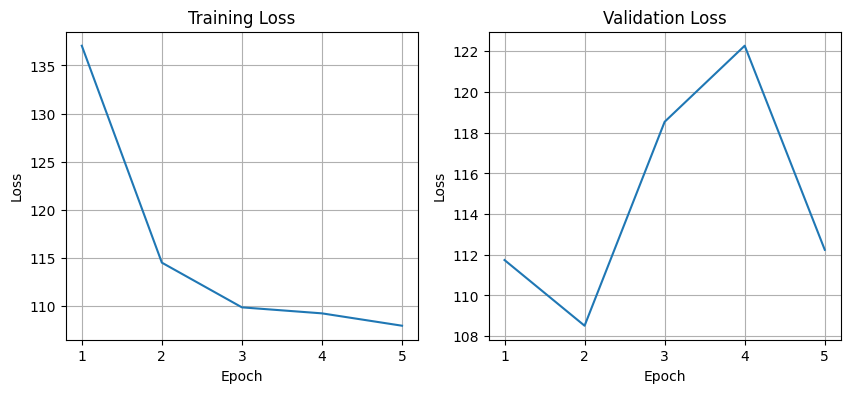

In [208]:
plot_loss(train_loss,val_loss)

torch.Size([1, 7, 7, 6])


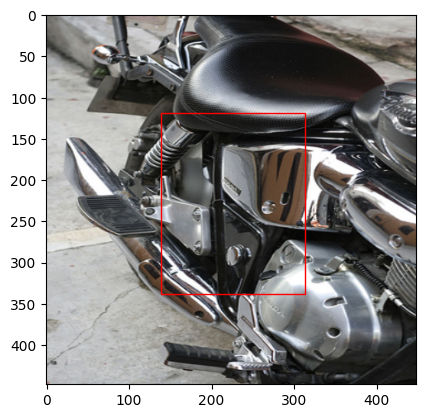

In [205]:
img_dir = "/kaggle/input/datasets/gopalbhattrai/pascal-voc-2012-dataset/VOC2012_test/VOC2012_test/JPEGImages/2008_000001.jpg"
Object_Detection(my_yolo,img_dir,transform)

Trick about grid !

In [ ]:
import torch 
S = 7
device = 'cuda'
cell_y, cell_x = torch.meshgrid(torch.arange(S, device=device), torch.arange(S, device=device), indexing='ij')
cell_y